In [1]:
import sys
from astropy import units as un, constants as cons
from astropy.cosmology import Planck18 as cosmo
import numpy as np
from matplotlib import pyplot as plt
import cmasher as cmr
from astropy.visualization import quantity_support
quantity_support()

from cgm_ics.latexify import latexify
from cgm_ics import solve_ode as CF
from cgm_ics import halo_potentials as Halo
from cgm_ics import cooling_functions as Cool

import warnings
warnings.simplefilter("ignore", RuntimeWarning)

import importlib # for testing : importlib.reload(module)

import pickle
from pathlib import Path

In [2]:
def save_solutions(solutions, filepath) -> None:
    """
    Save a list of CGMSolution objects to a file.
    
    Args:
        solutions: List of CGMSolution objects to save
        filepath: Path to save file (will add .pkl extension if not present)
    """
    filepath = Path(filepath)
    if filepath.suffix != '.pkl':
        filepath = filepath.with_suffix('.pkl')
    
    with open(filepath, 'wb') as f:
        pickle.dump(solutions, f)
    print(f"Saved {len(solutions)} solutions to {filepath}")

def load_solutions(filepath):
    """
    Load a list of CGMSolution objects from a file.
    
    Args:
        filepath: Path to the saved file
        
    Returns:
        List of CGMSolution objects
    """
    filepath = Path(filepath)
    if filepath.suffix != '.pkl':
        filepath = filepath.with_suffix('.pkl')
    
    with open(filepath, 'rb') as f:
        solutions = pickle.load(f)
    print(f"Loaded {len(solutions)} solutions from {filepath}")
    return solutions

In [3]:
# Set Cosmology
rho_crit = cosmo.critical_density0
rho_mean = cosmo.Om0*rho_crit
delta_c =  18 * np.pi**2 + 82 * (cosmo.Om0 - 1) - 39 * (cosmo.Om0 - 1)**2 # Bryan & Norman 98
mu = 0.62 # mean molecular weight

# Helper function for dervied values
def calc_r_vir(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / delta_c / rho_crit, 1/3)
    return r_vir.to('kpc')

def calc_r_200_c(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_crit, 1/3)
    return r_vir.to('kpc')
    
def calc_r_200_m(M_vir):
    r_vir = np.power(M_vir / (4/3) / np.pi / 200 / rho_mean, 1/3)
    return r_vir.to('kpc')

def calc_T_vir(M_vir):
    r_vir = calc_r_vir(M_vir)
    vc = np.sqrt(cons.G * M_vir / r_vir)
    temp = mu*cons.m_p*vc**2/cons.k_B/2
    return temp.to('K')

def calc_concentration(M_vir):
    h = cosmo.H0.value/100
    M_ref = 1e12/h * un.Msun
    log_c = 0.905 - 0.101*np.log10(M_vir/M_ref)
    return np.power(10, log_c)

def circular_temp(vc):
    temp = 0.6*mu*cons.m_p*vc**2/cons.k_B
    return temp.to('K')

# Set Halo Parameters
M_vir = 1e11 * un.Msun
r_vir = calc_r_vir(M_vir)
T_vir = calc_T_vir(M_vir)
c_vir = calc_concentration(M_vir) # Concentration parameter
r_200_m = calc_r_200_m(M_vir)
r_200_c = calc_r_200_c(M_vir)
M_gal = 1e10 * un.Msun # Greco et al 2012 for M82
r_gal = 0.015*r_200_c # Kravtsoc 2013 expression for stellar half-mass radius
z_gal = 0.15 * un.kpc # Lim et al 2013 for M82
      
print("Halo Mass: ",M_vir)
print("Virial Radius: ", r_vir)
print("Virial Temperature: ", T_vir)
print("Concentration Parameter: ", c_vir)
print("R200m: ", r_200_m)
print("R200c: ", r_200_c)
print("Disk Mass", M_gal)
print("Disk Scale Radius", r_gal)
print("Disk Scale Height", z_gal)

# Set Halo Potential
nfw = Halo.NFWPotential(M_vir, r_vir, c_vir)
plummer = Halo.PlummerPotential(M_gal, r_gal)
outer = Halo.OuterHaloPotential(rho_mean, r_200_m)
combined = Halo.CombinedPotential(M_vir, r_vir, c_vir, M_gal, r_gal, rho_mean, r_200_m)

Halo Mass:  100000000000.0 solMass
Virial Radius:  122.40315626626357 kpc
Virial Temperature:  131960.7175211719 K
Concentration Parameter:  10.54718269190388
R200m:  144.76736317842207 kpc
R200c:  97.94126310709676 kpc
Disk Mass 10000000000.0 solMass
Disk Scale Radius 1.4691189466064514 kpc
Disk Scale Height 0.15 kpc


In [4]:
# Set Cooling
cooling = Cool.Wiersma_Cooling(Z2Zsun=1.0/3,z=0)

In [5]:
r_ref = np.logspace(np.log10(0.01), np.log10(300), 500) * un.kpc
t_ff = (2**0.5 * r_ref / combined.vc(r_ref)).to('Gyr')
v_circ = combined.vc(r_ref).to('km/s')

In [6]:
# print(np.logspace(np.log10(12),np.log10(100),15)) # + 110
R_sonics = [12.        , 13.96220513, 16.24526433, 18.90164275, 21.99238444, \
            24.6       , 29.77267488, 34.64101615, 40.30541444, 46.89603868, \
            54.56434264, 63.48654538, 73.86768078, 85.94630928, 100.       , 110.0]*un.kpc
R_max = [350,350,350,350,341,\
         335,323,313,304,294,\
         284,273,261,246,230,218]*un.kpc

In [ ]:
max_step = 0.01                            # lowest resolution of solution in ln(r)
R_min    = 0.1*un.kpc                      # inner radius of supersonic part of solution

transsonic_solutions = []
for i, R_sonic in enumerate(R_sonics):
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions.append(CF.shoot_from_R_sonic(combined,
                                                      cooling,
                                                      R_sonic,
                                                      R_max[i],
                                                      R_min,
                                                      max_step=max_step,
                                                      verbose=True))

R_sonic = 12.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Unbound (Maximum r = 15 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Unbound (Maximum r = 31 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.375006 ... Stop reason: Unbound (Maximum r = 57 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.437506 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.406256 ... Stop reason: Unbound (Maximum r = 113 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.421881 ... Stop reason: Sonic point (Maximum r = 93 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.414068 ... Stop reason: Sonic point (Maximum r = 239 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.410162 ... Stop reason: Unbound (Maximum r = 188 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.412115 ... Stop reason: Sonic point (Maximum r = 306 kpc)
Integrating wit

In [51]:
# transsonic_solutions = []
max_step = 0.01                            # lowest resolution of solution in ln(r)
R_min    = 0.1*un.kpc                      # inner radius of supersonic part of solution
temp_sonic_solutions = []
for R_sonic in [11.0]*un.kpc:
    print('R_sonic = %s'%R_sonic)
    temp_sonic_solutions.append(CF.shoot_from_R_sonic(combined,
                        cooling,
                        R_sonic,
                        377*un.kpc,
                        R_min,
                        max_step=max_step,
                        verbose=True))

R_sonic = 11.0 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Unbound (Maximum r = 14 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.500005 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.250008 ... Stop reason: Unbound (Maximum r = 29 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.375006 ... Stop reason: Unbound (Maximum r = 54 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.437506 ... Stop reason: No transsonic solutions
Integrating with v_c^2/c_s^2 (R_sonic) = 1.406256 ... Stop reason: Unbound (Maximum r = 102 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.421881 ... Stop reason: Sonic point (Maximum r = 75 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.414068 ... Stop reason: Sonic point (Maximum r = 258 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.410162 ... Stop reason: Unbound (Maximum r = 143 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 1.412115 ... Stop reason: Sonic point (Maximum r = 347 kpc)
Integrating wit

In [71]:
# print(np.logspace(np.log10(0.6),np.log10(1.3),10)*un.kpc)
R_sonics2 = np.logspace(np.log10(0.6),np.log10(1.3),10)*un.kpc #sonic radii
R_max2 = 350*un.kpc # outer radius of integration

In [72]:
transsonic_solutions2 = []
for i, R_sonic in enumerate(R_sonics2):
    print('R_sonic = %s'%R_sonic)
    transsonic_solutions2.append(CF.shoot_from_R_sonic(combined,
                                                      cooling,
                                                      R_sonics2[i],
                                                      R_max2,
                                                      R_min,
                                                      max_step=max_step,
                                                      verbose=True))

R_sonic = 0.6 kpc
Integrating with v_c^2/c_s^2 (R_sonic) = 1.000010 ... Stop reason: Sonic point (Maximum r = 0 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.500015 ... Stop reason: Unbound (Maximum r = 2 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.750012 ... Stop reason: Sonic point (Maximum r = 1 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.625014 ... Stop reason: Unbound (Maximum r = 17 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.687513 ... Stop reason: Sonic point (Maximum r = 2 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.656263 ... Stop reason: Sonic point (Maximum r = 5 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.640639 ... Stop reason: Sonic point (Maximum r = 79 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.632826 ... Stop reason: Unbound (Maximum r = 33 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.636732 ... Stop reason: Unbound (Maximum r = 60 kpc)
Integrating with v_c^2/c_s^2 (R_sonic) = 0.638685 ... Stop reason: Sonic point (Maximum r = 324 kpc)
In

In [7]:
# Save
# save_solutions(transsonic_solutions, 'solutions/my_cgm_solutions_1')

# Load
loaded_solutions = load_solutions('solutions/my_cgm_solutions_1')

Loaded 16 solutions from solutions/my_cgm_solutions_1.pkl


In [8]:
# Save
# save_solutions(transsonic_solutions2, 'solutions/my_cgm_solutions_2')

# Load
loaded_solutions2 = load_solutions('solutions/my_cgm_solutions_2')

Loaded 10 solutions from solutions/my_cgm_solutions_2.pkl


0.6929616676997971 solMass / yr
0.7259411220552734 solMass / yr
0.7643998509969686 solMass / yr
0.8086931659593564 solMass / yr
0.8551191683136523 solMass / yr
0.8930941192408458 solMass / yr
0.9586689356951706 solMass / yr
1.01161673369004 solMass / yr
1.0662950292384432 solMass / yr
1.124847524886552 solMass / yr
1.1892762238384296 solMass / yr
1.2625689466171852 solMass / yr
1.3475764154363519 solMass / yr
1.4539695462149873 solMass / yr
1.5774823822077317 solMass / yr
1.664347813226834 solMass / yr


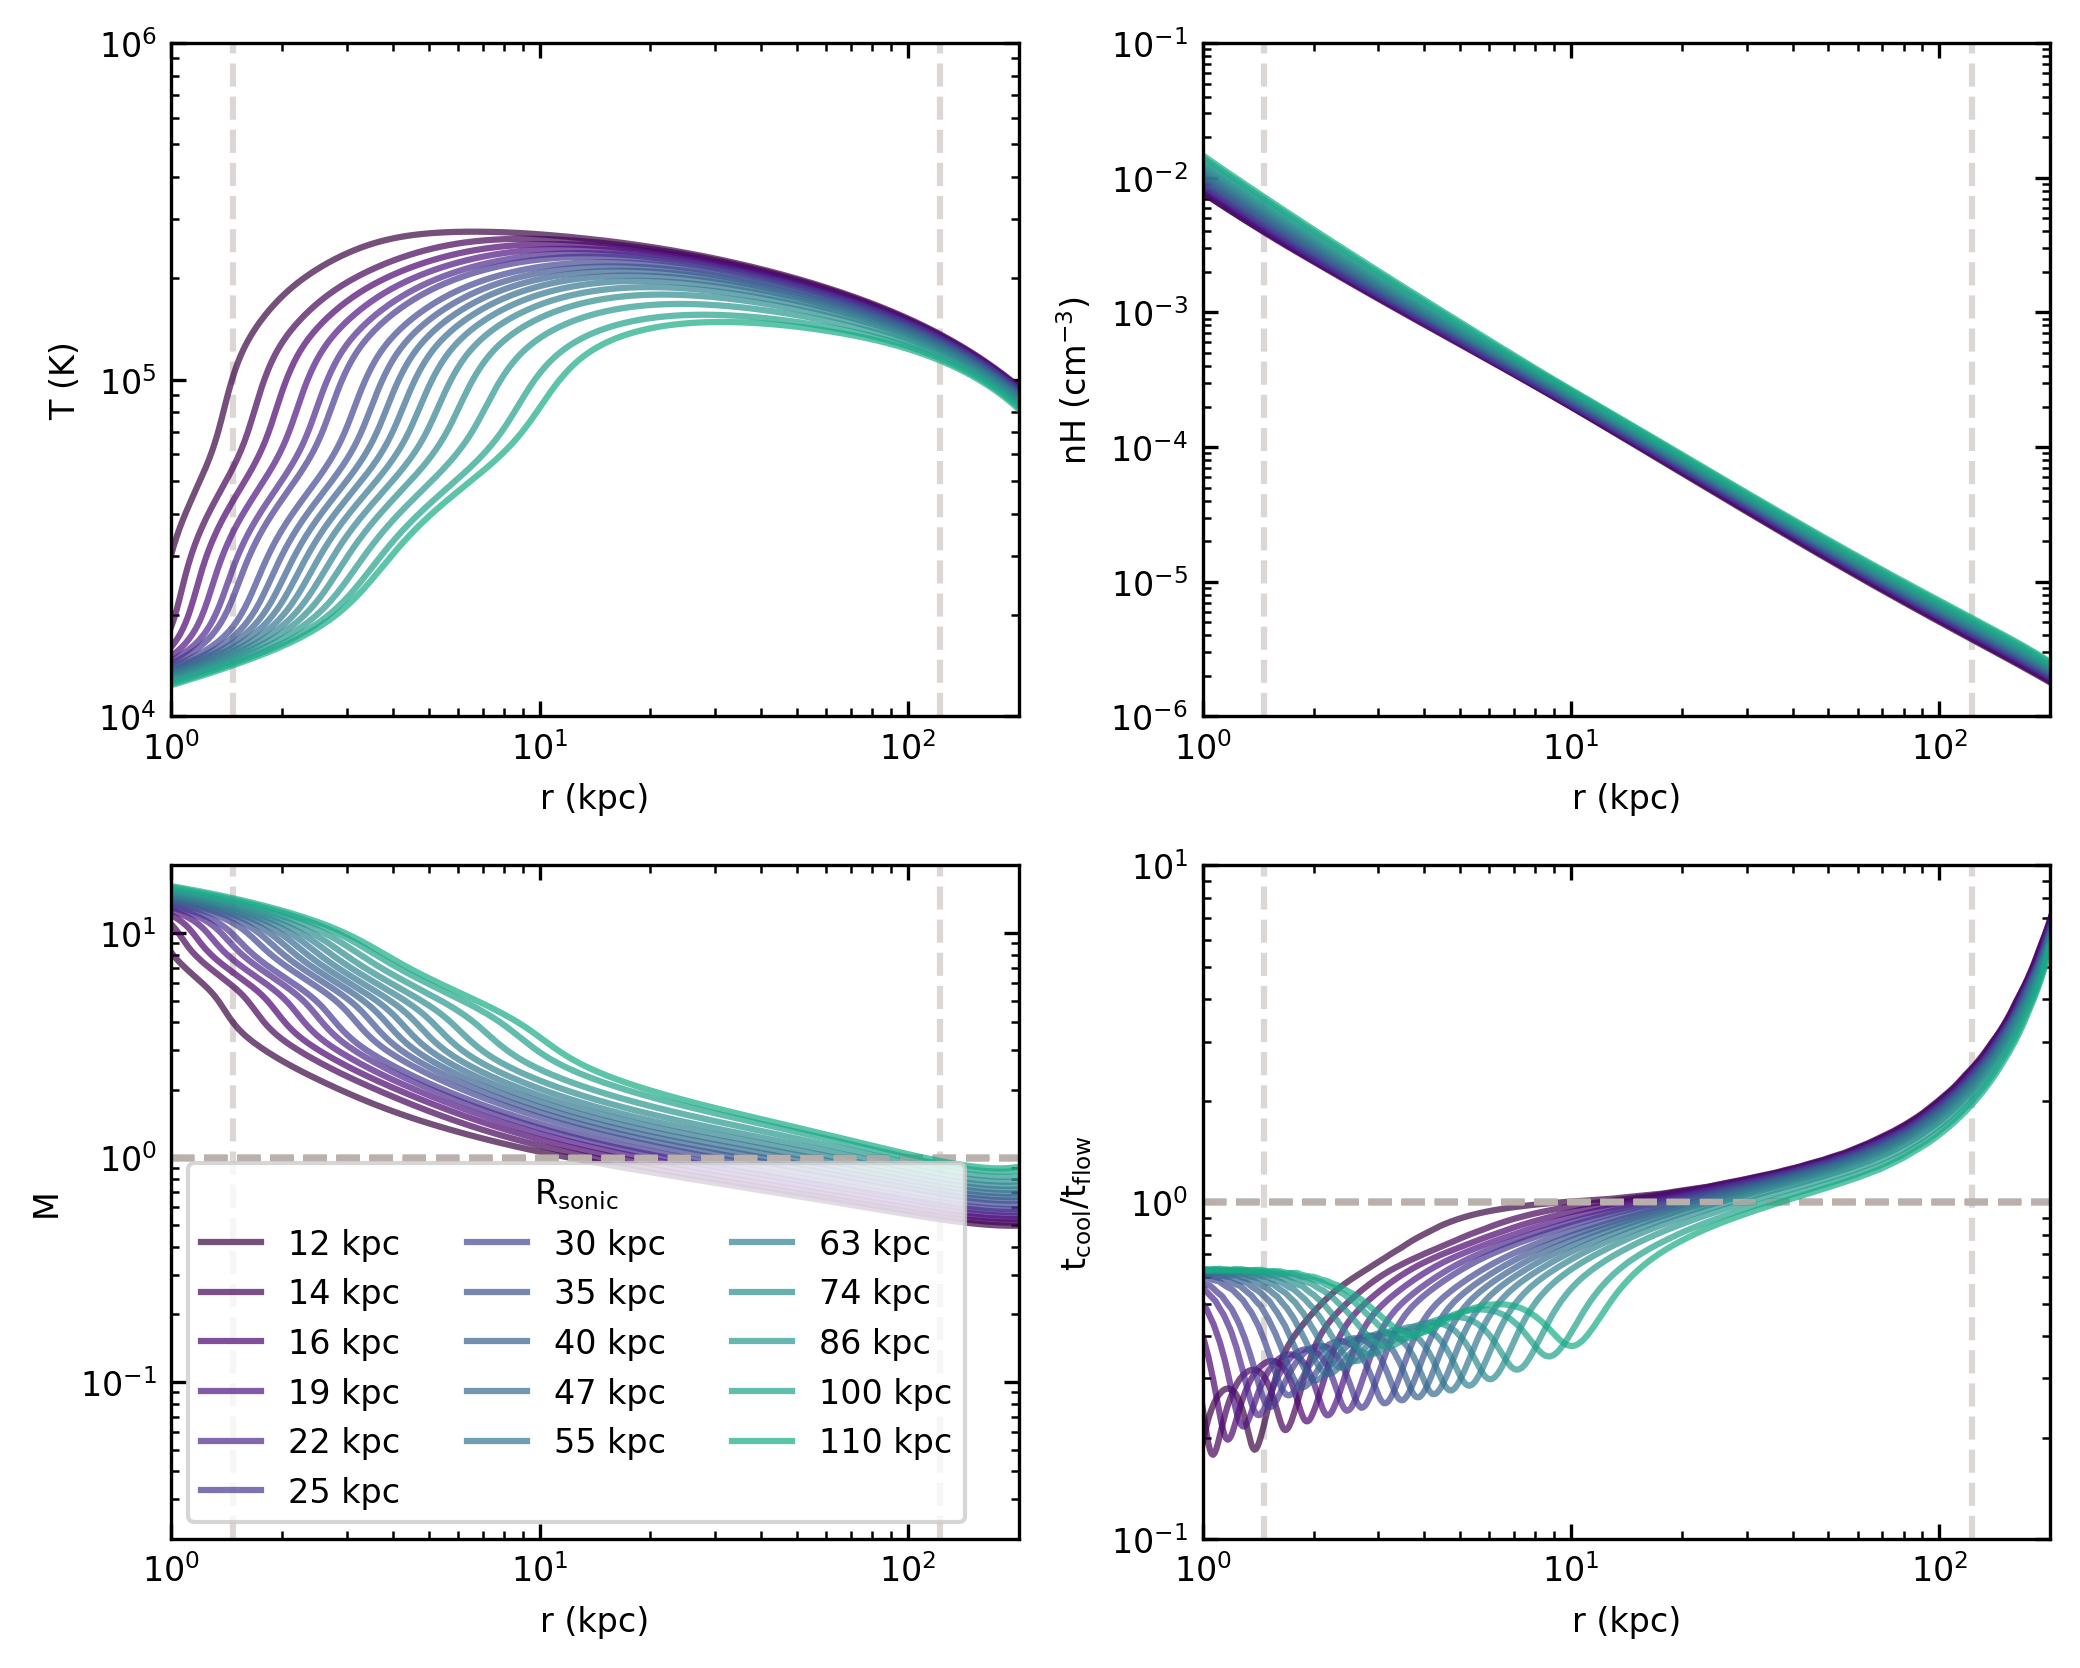

In [ ]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(1e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i],
                       label=f'{res.R_sonic:.0f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
                       label=f'{res.R_sonic:.0f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.02,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
# plt.savefig('./plots/cf_sols.pdf',dpi=300)
plt.show()

0.16357121861294305 solMass / yr
0.205187476654202 solMass / yr
0.2546616638337532 solMass / yr
0.3107278985928959 solMass / yr
0.3714407453538737 solMass / yr
0.4348338030021641 solMass / yr
0.49844185592039925 solMass / yr
0.5590243185544804 solMass / yr
0.6164728452449435 solMass / yr
0.6695046996817476 solMass / yr


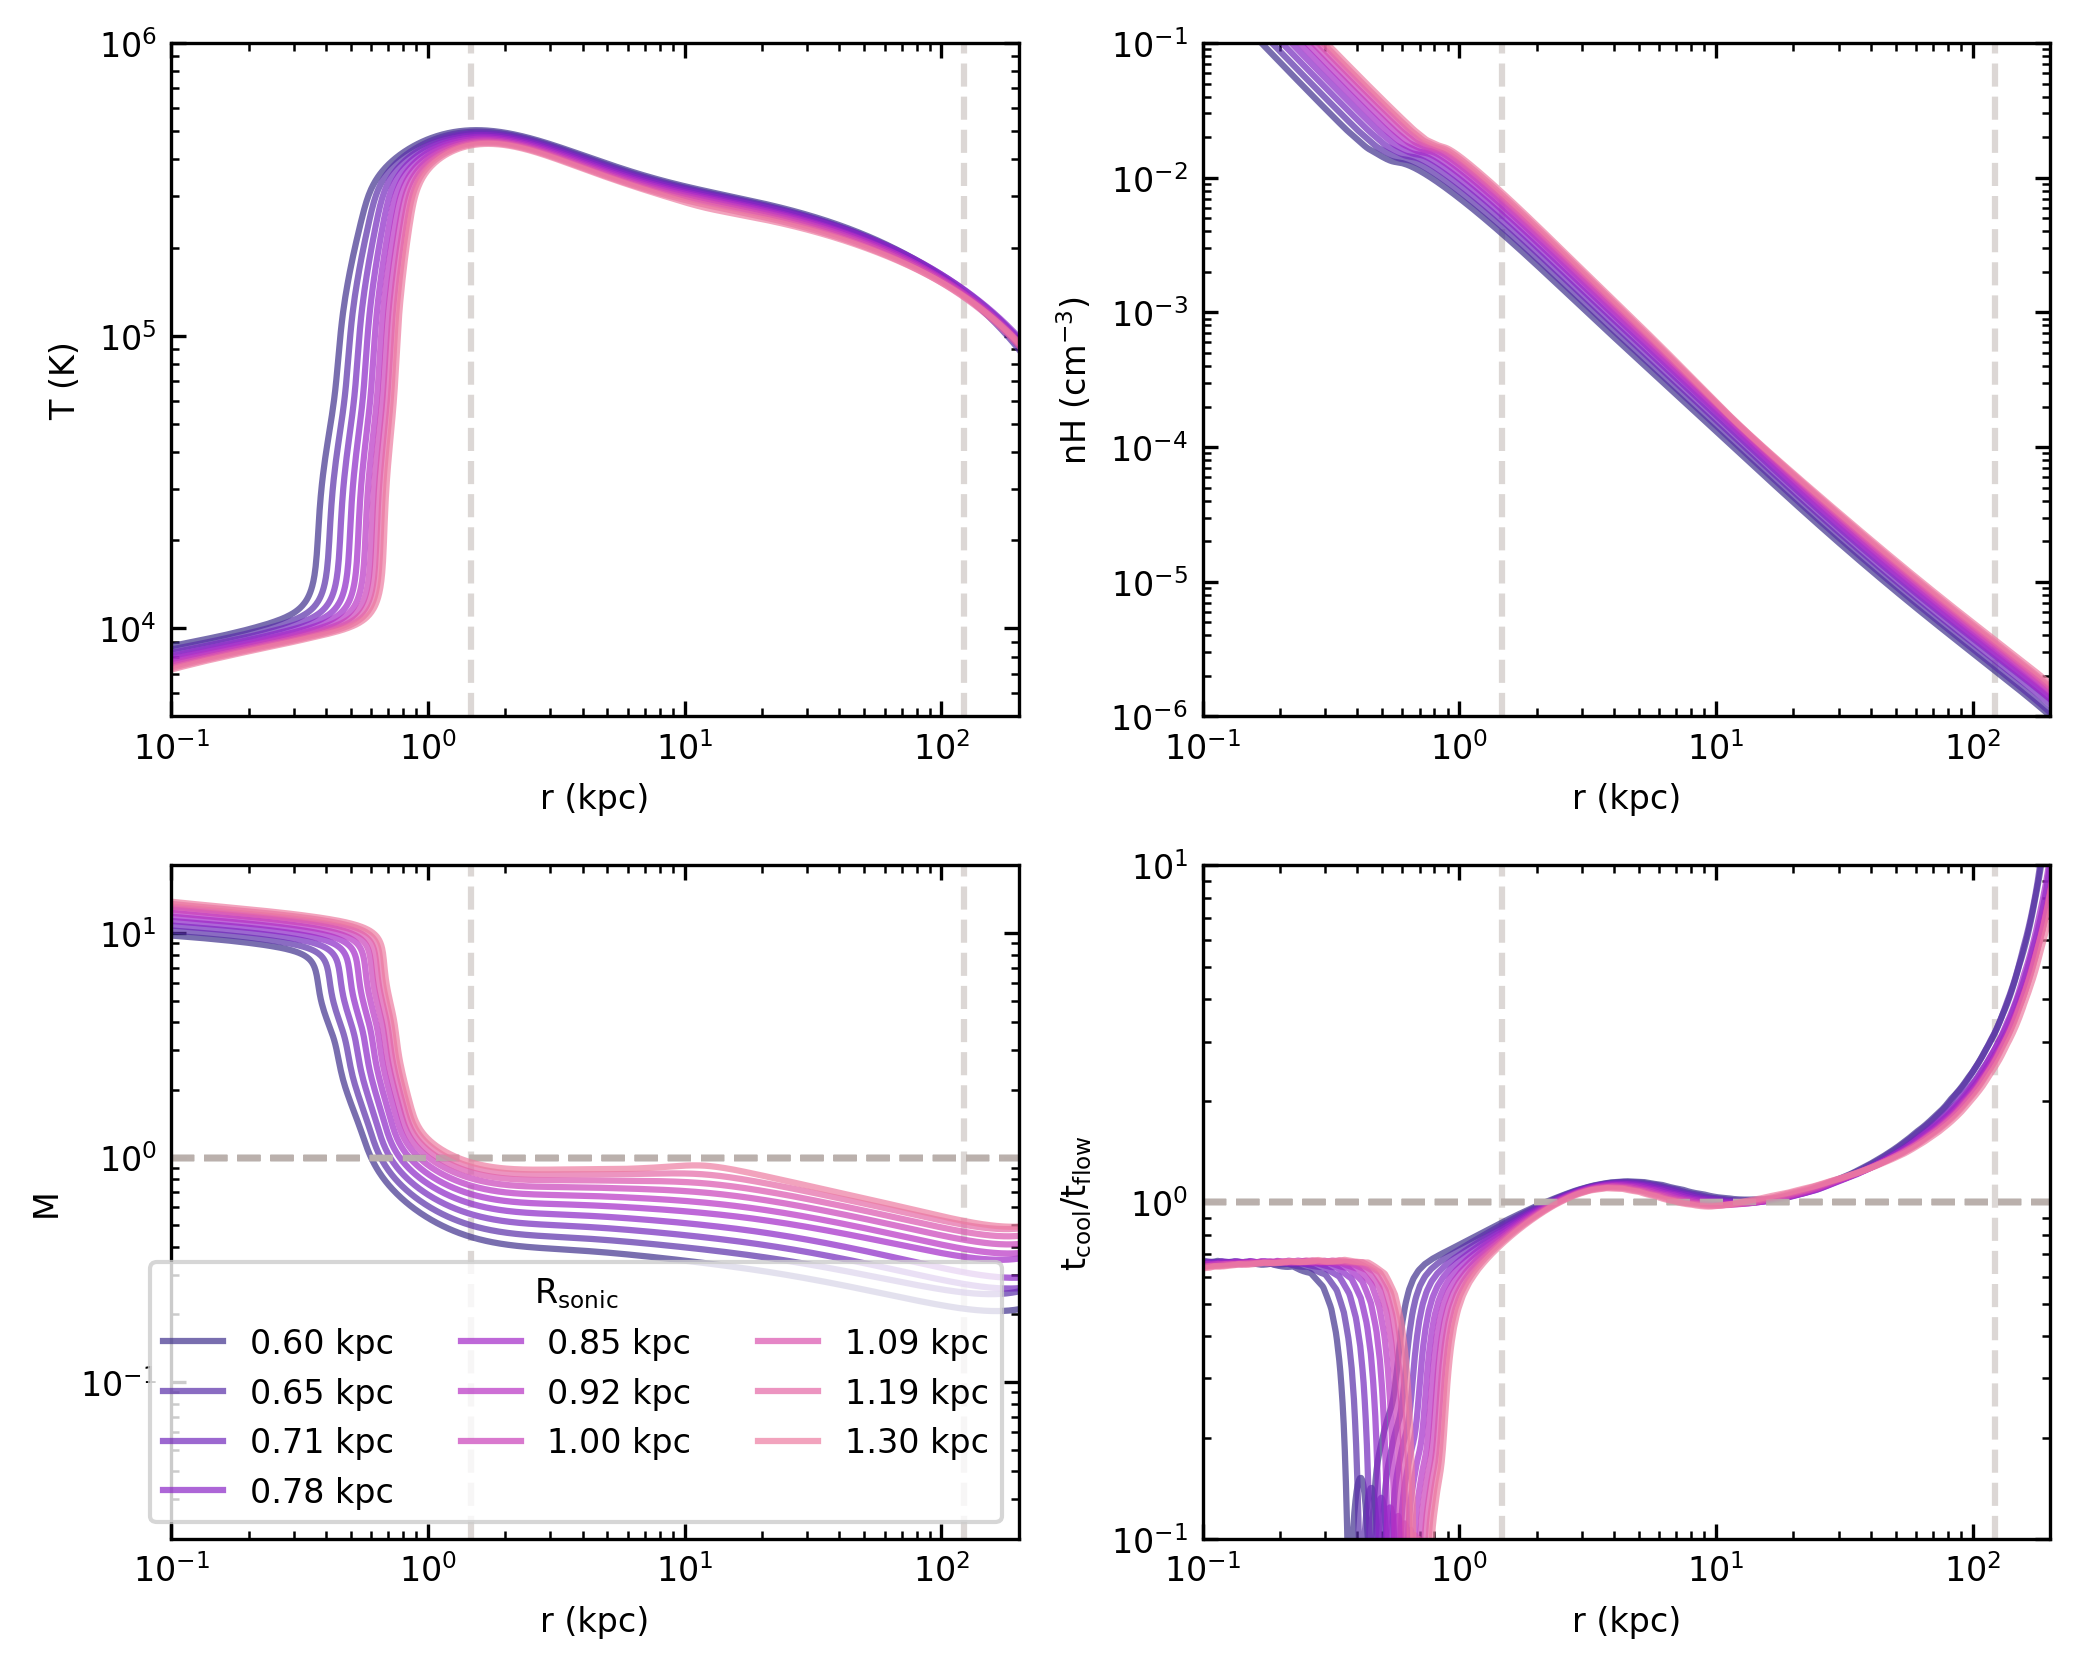

In [99]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(0.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors2[i],
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors2[i], 
                       label=f'{res.R_sonic:.2f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.02,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

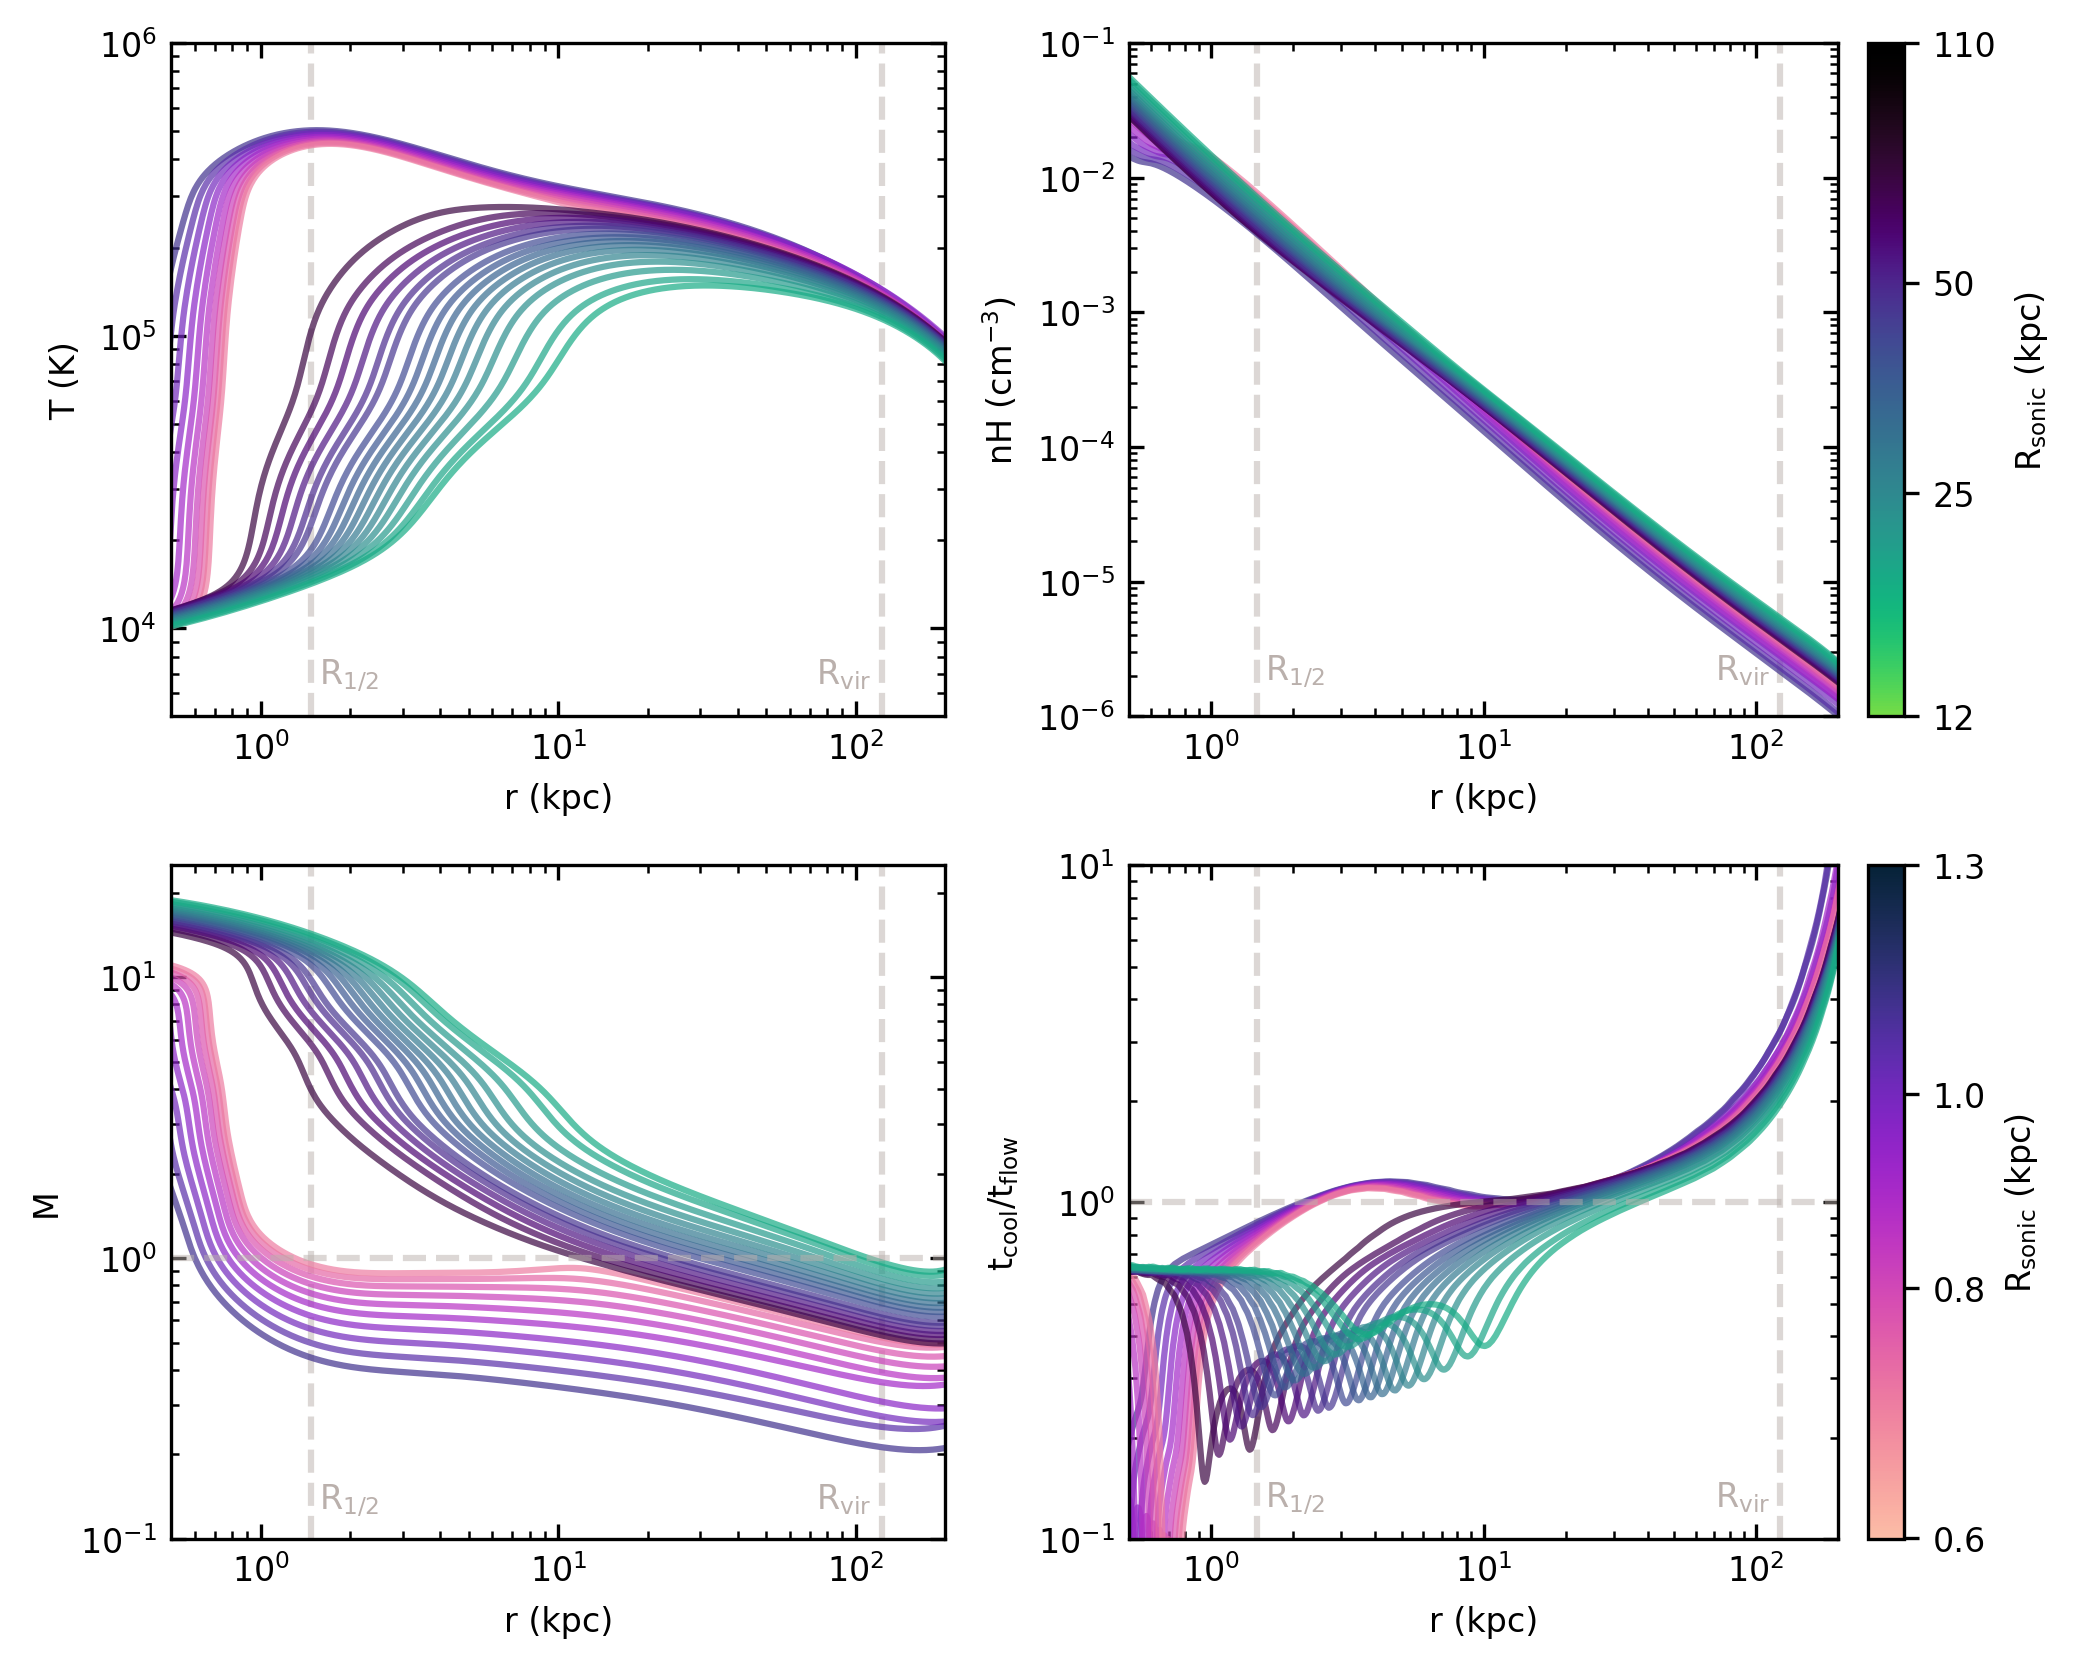

In [9]:
from matplotlib.colors import Normalize, LogNorm
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(.5,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

# Get sonic radii values for colorbar normalization
sonic_radii_1 = [res.R_sonic.to('kpc').value for res in loaded_solutions if res is not None]
sonic_radii_2 = [res.R_sonic.to('kpc').value for res in loaded_solutions2 if res is not None]

norm1 = LogNorm(vmin=min(sonic_radii_1), vmax=max(sonic_radii_1))
norm2 = LogNorm(vmin=min(sonic_radii_2), vmax=max(sonic_radii_2))

cmap1 = cmr.lavender
cmap2 = cmr.bubblegum

for i, res in enumerate(loaded_solutions2):
    if res is not None:
        log_frac = (np.log10(res.R_sonic.to('kpc').value) - np.log10(min(sonic_radii_2))) / \
                   (np.log10(max(sonic_radii_2)) - np.log10(min(sonic_radii_2)))
        color = cmap2(0.2 + 0.6 * log_frac)
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=color)
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=color)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=color)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=color)


for i, res in enumerate(loaded_solutions):
    if res is not None:
        # Map sonic radius to colormap range [0.2, 0.8] in log space
        log_frac = (np.log10(res.R_sonic.to('kpc').value) - np.log10(min(sonic_radii_1))) / \
                   (np.log10(max(sonic_radii_1)) - np.log10(min(sonic_radii_1)))
        color = cmap1(0.2 + 0.6 * log_frac)
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=color)
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=color)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=color)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=color)

# Set labels and limits
axs[0, 0].set_ylabel(r'T (K)')
axs[0, 0].set_ylim(.5e4,1e6)
axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
axs[0, 1].set_ylim(1e-6,1e-1)
axs[1, 0].set_ylabel(r'M')
axs[1, 0].set_ylim(0.1,25)
axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
axs[1, 1].set_ylim(0.1,10)
axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)

plt.tight_layout()

# Create colorbars
divider1 = make_axes_locatable(axs[0, 1])
cbar_ax1 = divider1.append_axes("right", size="5%", pad=0.1)

divider2 = make_axes_locatable(axs[1, 1])
cbar_ax2 = divider2.append_axes("right", size="5%", pad=0.1)

# ScalarMappables with log norm, mapped to colormap range [0.2, 0.8]
sm1 = ScalarMappable(cmap=cmr.lavender_r, 
                            norm=LogNorm(vmin=min(sonic_radii_1), 
                                         vmax=max(sonic_radii_1)))
sm2 = ScalarMappable(cmap=cmr.bubblegum_r, 
                            norm=LogNorm(vmin=min(sonic_radii_2), 
                                        vmax=max(sonic_radii_2)))

cbar1 = fig.colorbar(sm1, cax=cbar_ax1)
cbar2 = fig.colorbar(sm2, cax=cbar_ax2)

cbar1.ax.set_yticks([], minor=True)
cbar1.set_ticks([12, 25, 50, 110])
cbar1.set_ticklabels(['12', '25', '50', '110'])
cbar1.set_label(r'R$_{\rm sonic}$ (kpc)')

cbar2.ax.set_yticks([], minor=True)
cbar2.set_ticks([0.6, 0.8, 1.0, 1.3])
cbar2.set_ticklabels(['0.6', '0.8', '1.0', '1.3'])
cbar2.set_label(r'R$_{\rm sonic}$ (kpc)')

axs[0, 0].text(r_gal.value+0.1, 8e3, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')
axs[0, 1].text(r_gal.value+0.1, 3e-6, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')
axs[1, 0].text(r_gal.value+0.1, 0.16, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')
axs[1, 1].text(r_gal.value+0.1, 0.15, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')

axs[0, 0].text(r_vir.value-10, 8e3,  r'R$_{\rm vir}$', color='C9', ha='right', va='top')
axs[0, 1].text(r_vir.value-10, 3e-6, r'R$_{\rm vir}$', color='C9', ha='right', va='top')
axs[1, 0].text(r_vir.value-10, 0.16, r'R$_{\rm vir}$', color='C9', ha='right', va='top')
axs[1, 1].text(r_vir.value-10, 0.15, r'R$_{\rm vir}$', color='C9', ha='right', va='top')

plt.tight_layout()

# plt.savefig('./plots/cf_sols.pdf',dpi=300)
plt.show()

0.6929616676997971 solMass / yr
0.6695046996817476 solMass / yr
0.6791358254115584 solMass / yr


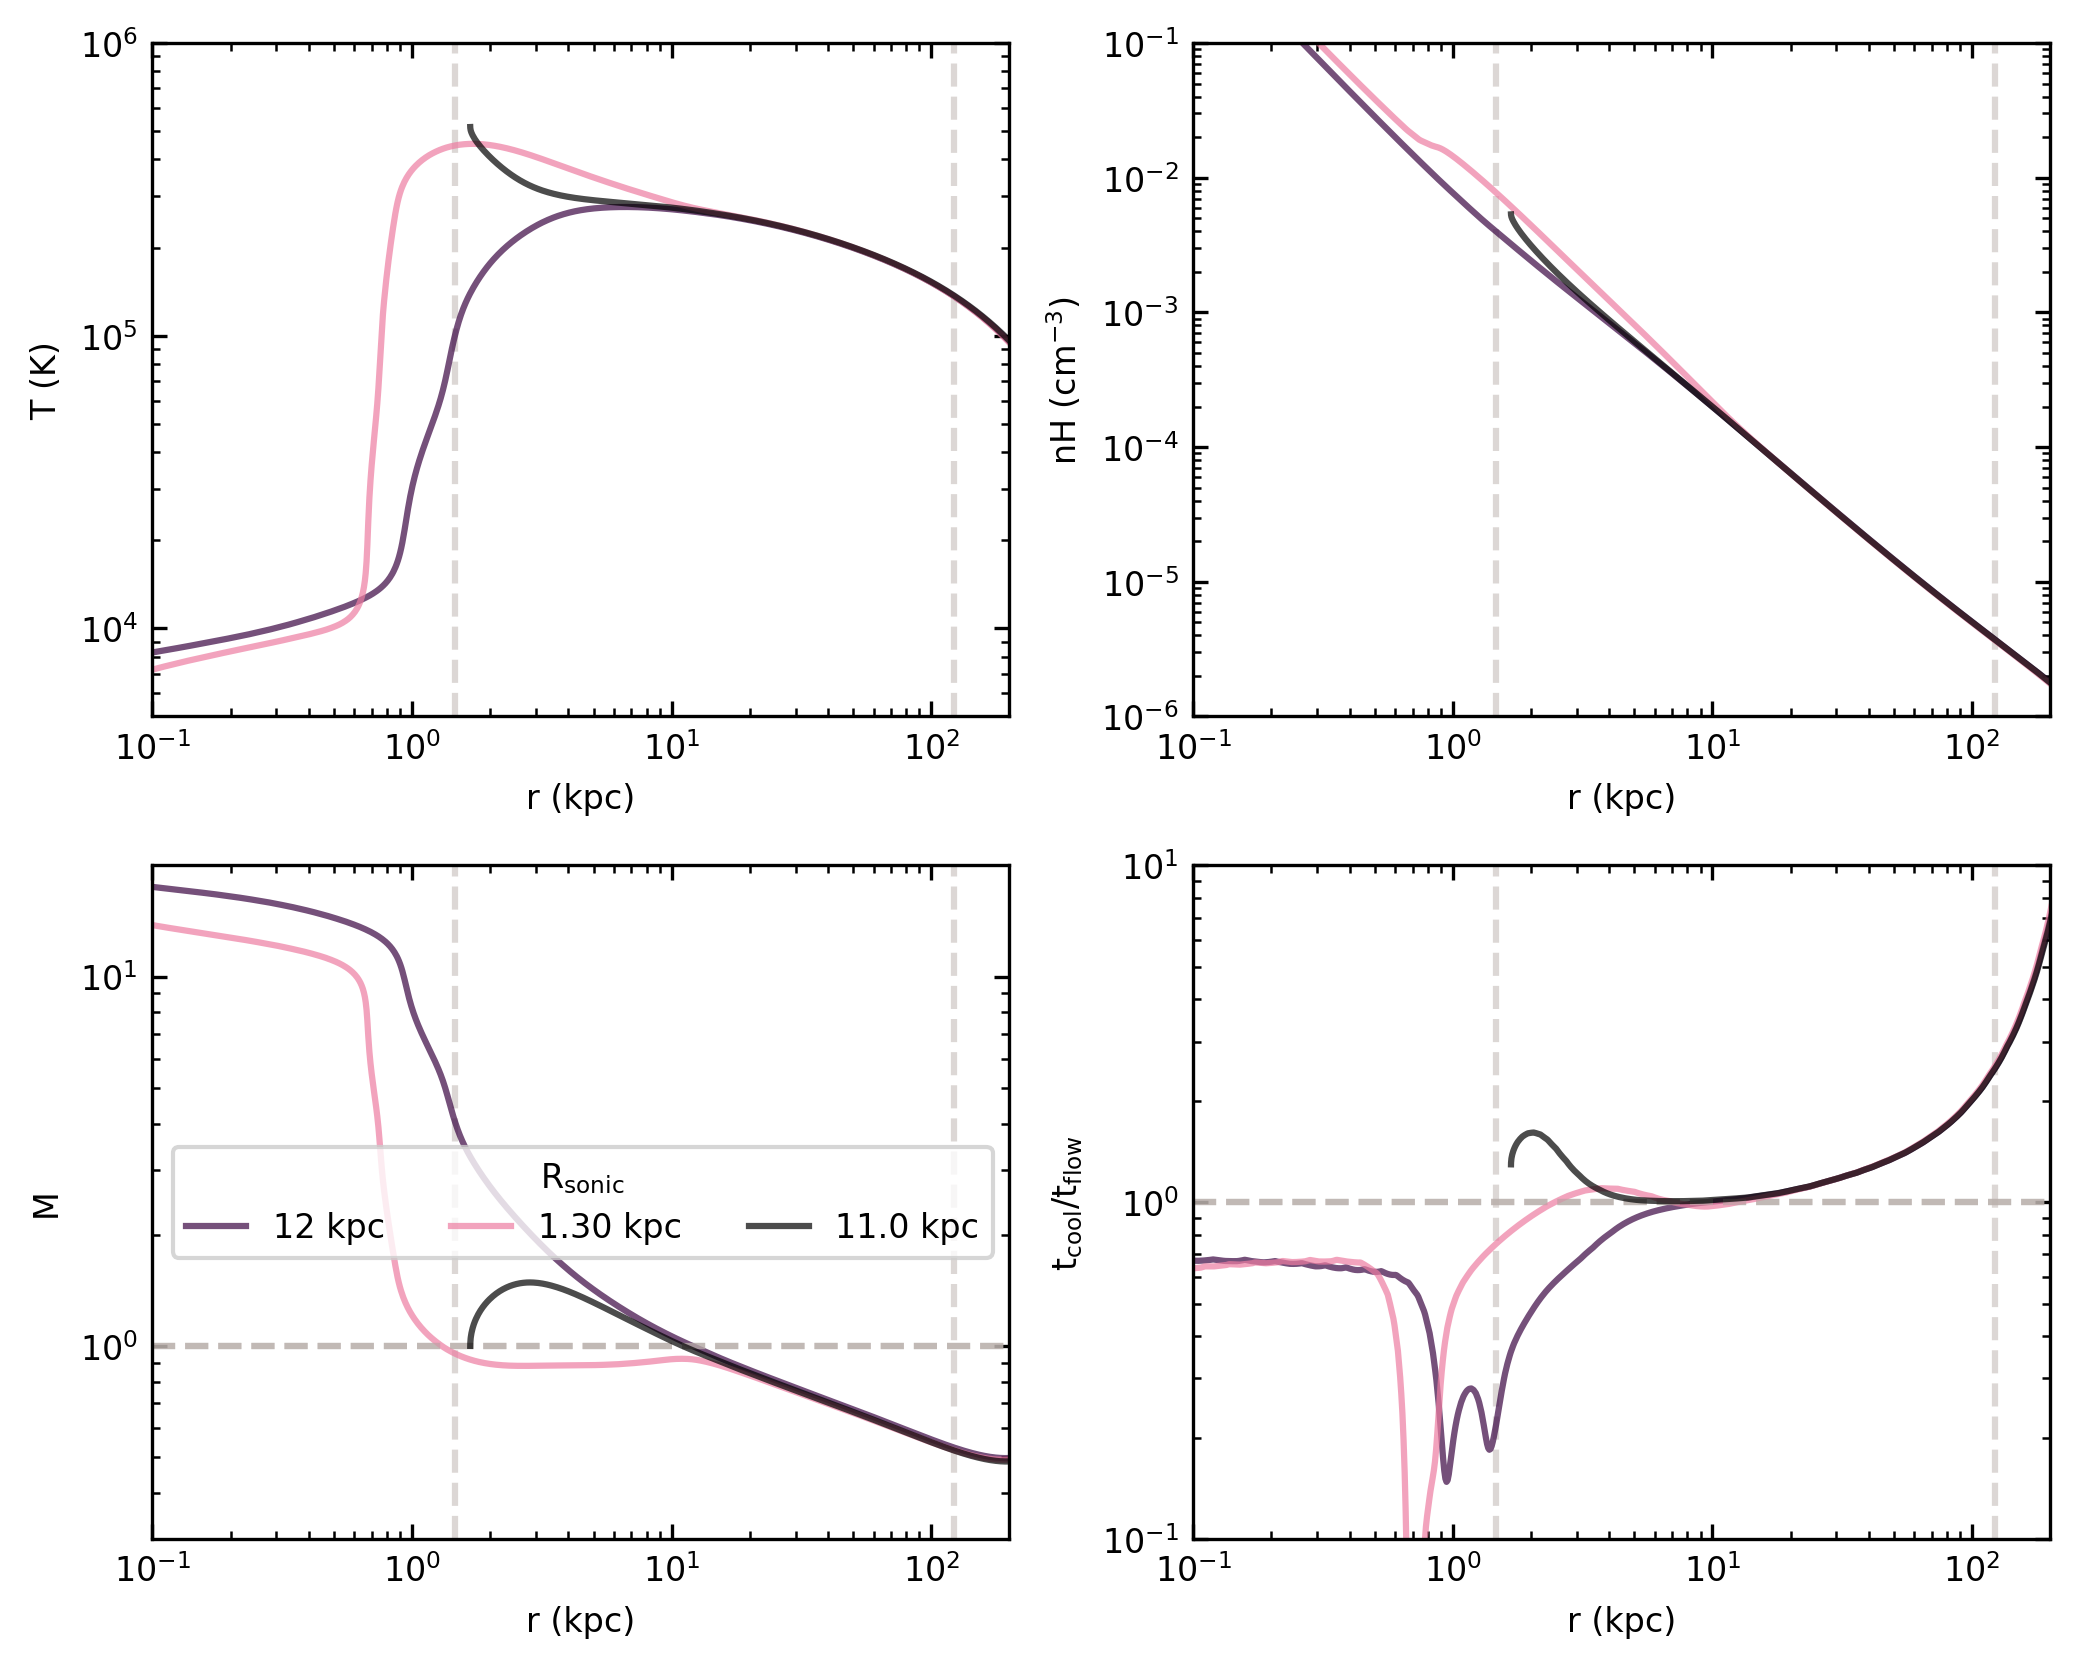

In [57]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in [0]:
    res = loaded_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])

        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i],
                       label=f'{res.R_sonic:.0f}')

        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
                       label=f'{res.R_sonic:.0f}')

        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])

        # print(res.mass_flow_rate)


colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))

for i in [-1]:
    res = loaded_solutions2[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i])
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors2[i],
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors2[i], 
                       label=f'{res.R_sonic:.2f}')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.3,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)

for i in [-1]:
    res = temp_sonic_solutions[i]
    print(res.mass_flow_rate)
    if res is not None:
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color='black')
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color='black',
                       label=f'{res.R_sonic:.2f}')
        axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
        axs[0, 1].set_ylim(1e-6,1e-1)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color='black', 
                       label=f'11.0 kpc')
        axs[1, 0].set_ylabel(r'M')
        axs[1, 0].set_ylim(0.3,20)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color='black')
        axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
        axs[1, 1].set_ylim(0.1,10)

        # print(res.mass_flow_rate)


axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
plt.tight_layout()
plt.show()

0.6695046996817476 solMass / yr


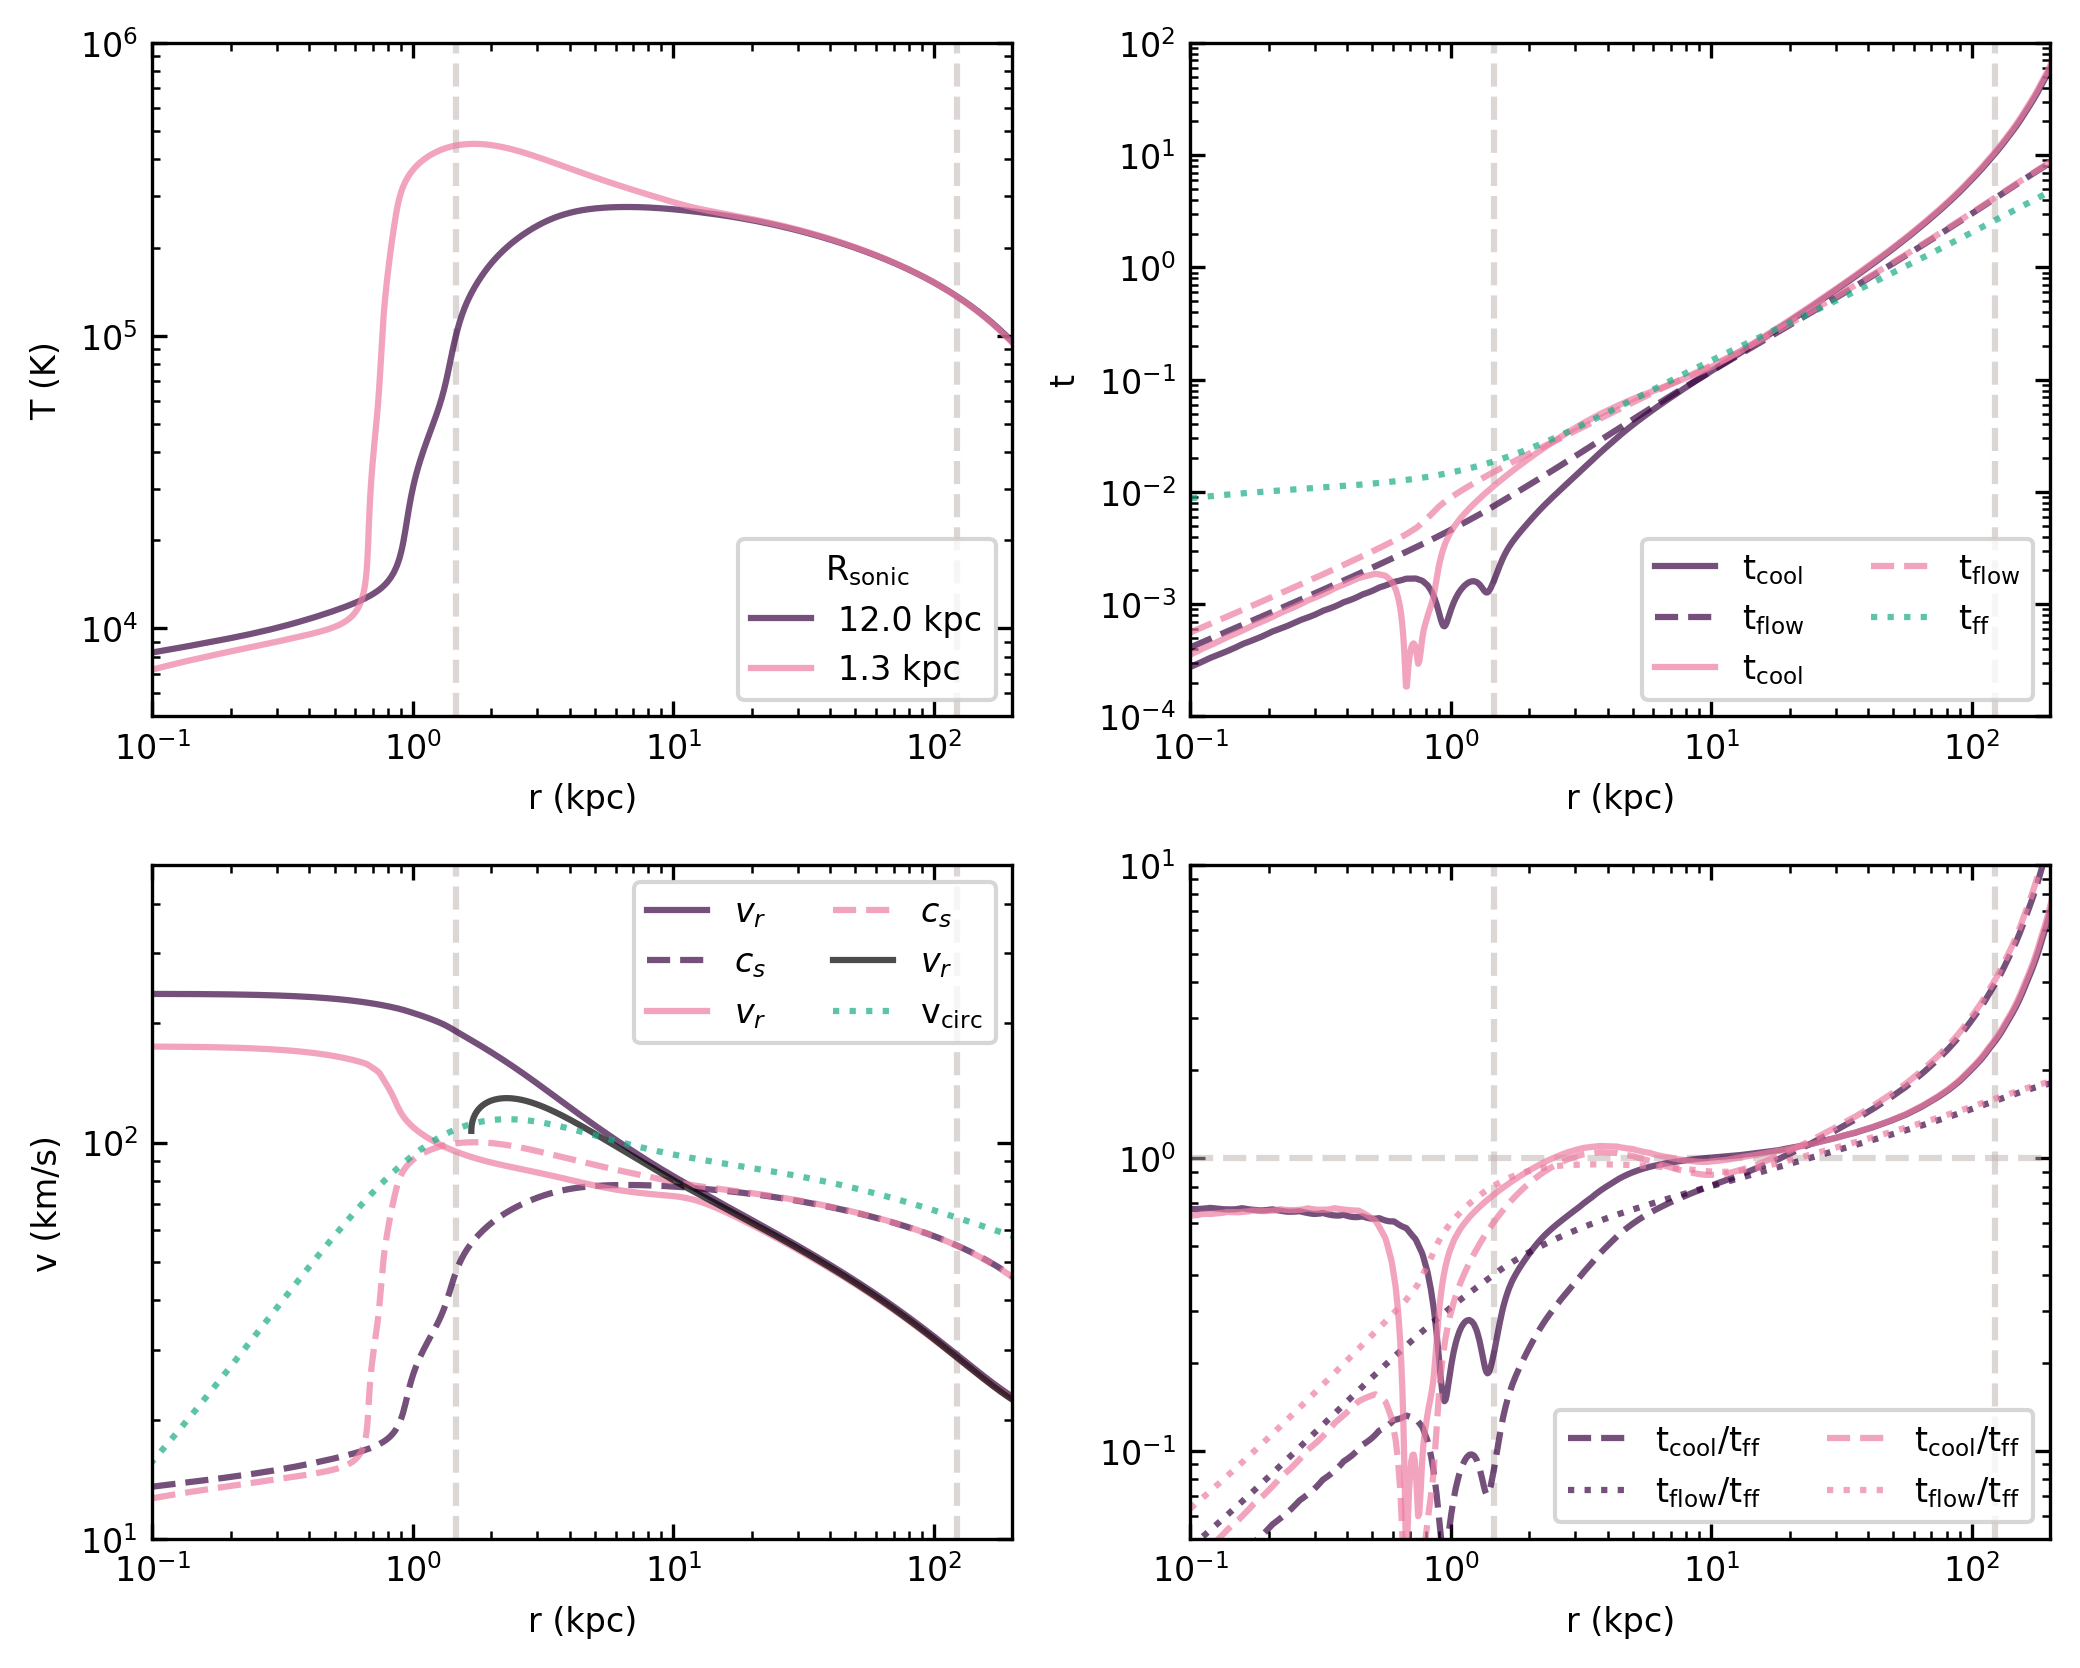

In [58]:
latexify(columns=2)
fig, axs = plt.subplots(2, 2)

for ax in axs.flatten():
    ax.set_xlabel(r'r (kpc)')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(top=True, right=True, which="both", direction='in')
    ax.set_xlim(0.1,200)

    ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
    ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)


colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
for i in [0]:
    res = loaded_solutions[i]
    if res is not None:
        t_ff_res = (2**0.5 * res.Rs / combined.vc(res.Rs)).to('Gyr')
        
        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i],
                        label=f'{res.R_sonic:.1f}')
        axs[0, 0].set_ylabel(r'T (K)')
        axs[0, 0].set_ylim(.5e4,1e6)
        
        axs[0, 1].plot(res.Rs, res.t_cools, alpha=0.7, color=colors[i], label=r't$_{\rm cool}$')
        axs[0, 1].plot(res.Rs, res.t_flows, alpha=0.7, color=colors[i], label=r't$_{\rm flow}$', ls='--')
        axs[0, 1].set_ylabel(r't')
        axs[0, 1].set_ylim(1e-4,1e2)
        
        axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color=colors[i], label=r'$v_r$')
        axs[1, 0].plot(res.Rs, res.cs, alpha=0.7, color=colors[i], ls='--',label=r'$c_s$')
        axs[1, 0].set_ylabel(r'v (km/s)')
        axs[1, 0].set_ylim(10,500)
        
        axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
        axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color=colors[i], ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color=colors[i], ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')
        axs[1, 1].set_ylim(0.05,10)

colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))
for i in [-1]:
    res = loaded_solutions2[i]
    print(res.mass_flow_rate)
    if res is not None:
        t_ff_res = (2**0.5 * res.Rs / combined.vc(res.Rs)).to('Gyr')

        axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors2[i],
                        label=f'{res.R_sonic:.1f}')
        
        axs[0, 1].plot(res.Rs, res.t_cools, alpha=0.7, color=colors2[i], label=r't$_{\rm cool}$')
        axs[0, 1].plot(res.Rs, res.t_flows, alpha=0.7, color=colors2[i], label=r't$_{\rm flow}$', ls='--')
        
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color=colors2[i], label=r'$v_r$')
        axs[1, 0].plot(res.Rs, res.cs, alpha=0.7, color=colors2[i], ls='--',label=r'$c_s$')

        axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors2[i])
        axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color=colors2[i], ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color=colors2[i], ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')


for i in [-1]:
    res = temp_sonic_solutions[i]
    if res is not None:
        axs[1, 0].plot(res.Rs, res.vs, alpha=0.7, color='black', label=r'$v_r$')

        # axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color='black')
        # axs[1, 1].plot(res.Rs, res.t_cools / t_ff_res, alpha=0.7, color='black', ls='--',label=r't$_{\rm cool}/$t$_{\rm ff}$')
        # axs[1, 1].plot(res.Rs, res.t_flows / t_ff_res, alpha=0.7, color='black', ls=':',label=r't$_{\rm flow}/$t$_{\rm ff}$')

axs[0, 1].plot(r_ref, t_ff, alpha=0.7, color=colors[i], label=r't$_{\rm ff}$', ls=':')
axs[1, 0].plot(r_ref, v_circ, alpha=0.7, color=colors[i], label=r'v$_{\rm circ}$', ls=':')

axs[0, 0].legend(frameon=True, ncols=1, title=r'R$_{\rm sonic}$', handlelength=1.8, loc='lower right')
axs[0, 1].legend(frameon=True, ncols=2, handlelength=1.8, loc='lower right')
axs[1, 0].legend(frameon=True, ncols=2, handlelength=1.8, loc='upper right')
axs[1, 1].legend(frameon=True, ncols=2, handlelength=1.8, loc='lower right')

plt.tight_layout()
plt.show()

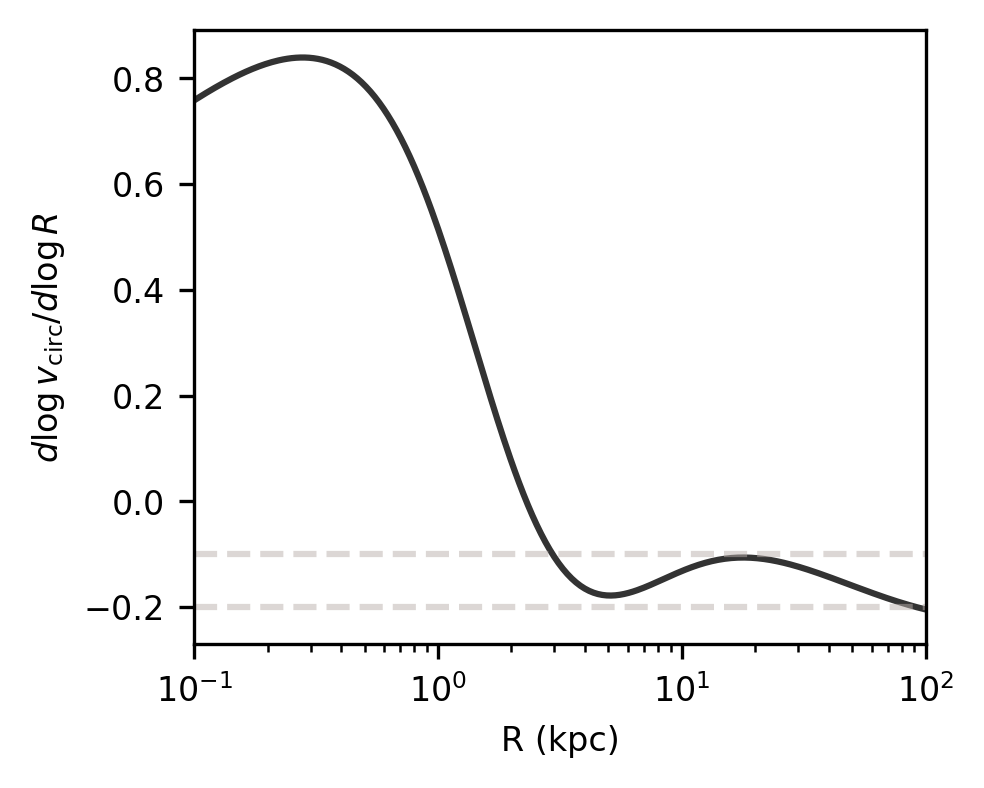

In [15]:
latexify(1)
plt.figure()

log_r = np.log10(r_ref.to('kpc').value)
log_v = np.log10(v_circ.to('km/s').value)
power_law_slope = np.gradient(log_v, log_r)

plt.plot(r_ref.to('kpc').value, power_law_slope, alpha=0.8, color='black')

plt.hlines(-0.1,1e-1,1e2,colors='C9',ls='--',alpha=0.5)
plt.hlines(-0.2,1e-1,1e2,colors='C9',ls='--',alpha=0.5)

plt.xscale('log')
# plt.ylim(-5,5)
plt.xlim(1e-1, 1e2)
plt.xlabel(r'R (kpc)')
plt.ylabel(r'$d\log v_{\rm circ}/d\log R$')
plt.tight_layout()
plt.show()

Highlighted Mdot: 1.01161673369004 solMass / yr 34.60637513385 kpc
Highlighted Mdot: 0.2546616638337532 solMass / yr 0.7117659461454925 kpc


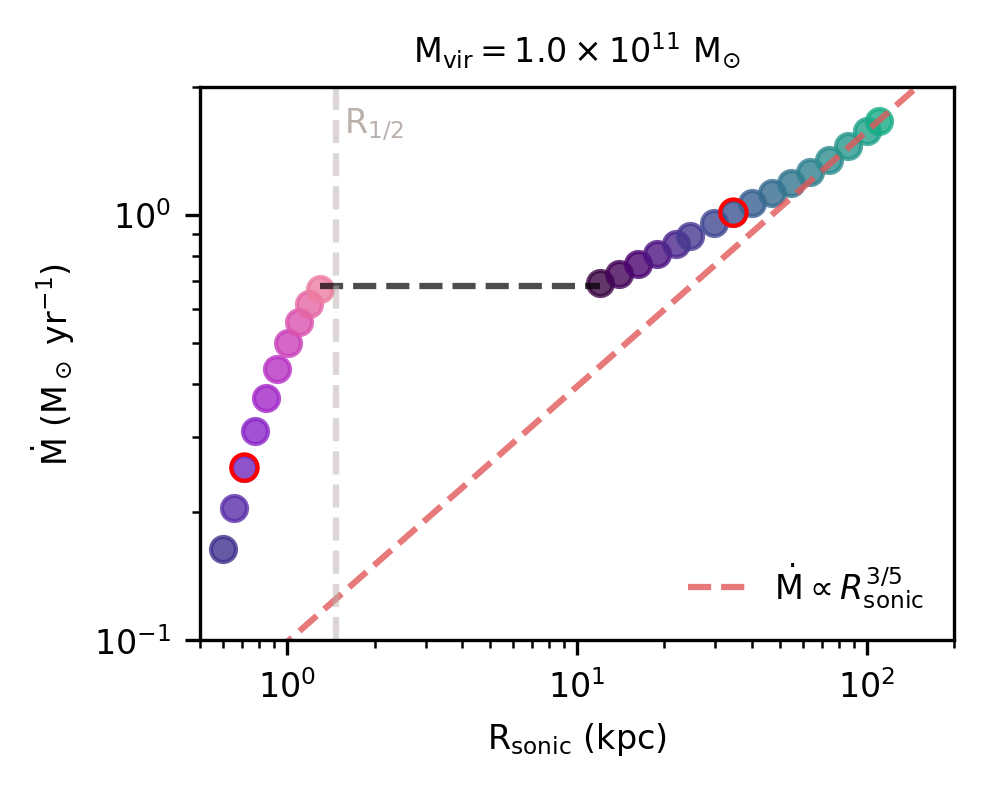

In [37]:
latexify(columns=1)
plt.figure()
ax = plt.gca()

colors = cmr.lavender(np.linspace(0.2,0.8,len(loaded_solutions)))
colors2 = cmr.bubblegum(np.linspace(0.2,0.8,len(loaded_solutions2)))

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        # print(res.mass_flow_rate)
        plt.scatter(res.R_sonic, res.mass_flow_rate, alpha=0.8, color=colors[i])

fit_rs = np.logspace(np.log10(0.5), np.log10(200), 100)
fit = [loaded_solutions[-1].mass_flow_rate.value*(r/loaded_solutions[-1].R_sonic.value)**0.6 for r in fit_rs]
plt.plot(fit_rs, fit, c='C2', ls='--', alpha=0.8,
         label=r'$\dot{\rm M}\propto R_{\rm sonic}^{3/5}$')

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        # print(res.mass_flow_rate)
        plt.scatter(res.R_sonic, res.mass_flow_rate, alpha=0.8, color=colors2[i])

# for i in range(len(temp_sonic_solutions)):
#     res = temp_sonic_solutions[i]
#     if res is not None:
#         # print(res.mass_flow_rate)
#         plt.scatter(res.R_sonic, res.mass_flow_rate, alpha=0.8, color='black')
        
plt.hlines((loaded_solutions2[-1].mass_flow_rate+loaded_solutions[0].mass_flow_rate)/2, 
           loaded_solutions2[-1].R_sonic, loaded_solutions[0].R_sonic, colors='black', linestyles='--', alpha=0.7)
# plt.hlines(loaded_solutions[0].mass_flow_rate,   loaded_solutions2[-1].R_sonic, loaded_solutions[0].R_sonic, colors='C9', linestyles='--', alpha=0.8)
# plt.hlines(loaded_solutions2[-1].mass_flow_rate, 0.5, 200, colors='C9', linestyles='--', alpha=0.8)

plt.scatter(loaded_solutions[7].R_sonic, loaded_solutions[7].mass_flow_rate, s=40, edgecolor='red', facecolors='none')
print('Highlighted Mdot:', loaded_solutions[7].mass_flow_rate, loaded_solutions[7].R_sonic)
plt.scatter(loaded_solutions2[2].R_sonic, loaded_solutions2[2].mass_flow_rate, s=40, edgecolor='red', facecolors='none')
print('Highlighted Mdot:', loaded_solutions2[2].mass_flow_rate, loaded_solutions2[2].R_sonic)

# plt.hlines(loaded_solutions[7].mass_flow_rate, 0.5, loaded_solutions[7].R_sonic-5*un.kpc, colors='red', linestyles='--', alpha=0.7)
# plt.hlines(loaded_solutions2[2].mass_flow_rate, 0.5, loaded_solutions2[2].R_sonic-0.1*un.kpc, colors='red', linestyles='--', alpha=0.7)

plt.vlines(r_gal,0.1,4,colors='C9',ls='--',alpha=0.5)

# label the galactic radius line
plt.text(r_gal.value+0.1, 1.8, r'R$_{\rm 1/2}$', color='C9', ha='left', va='top')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(0.1, 2)
ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'$\dot{\rm M}$ (M$_\odot$ yr$^{-1}$)')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8, loc='lower right')
plt.title(r'M$_{\rm vir} = 1.0 \times 10^{11}$ M$_{\odot}$')
plt.tight_layout()
plt.savefig('./plots/mdot_vs_rsonic.pdf',dpi=300)
plt.show()

In [16]:
for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        print(f'{res.R_sonic:.2f} {res.mass_flow_rate:.2f}')

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        print(f'{res.R_sonic:.2f} {res.mass_flow_rate:.2f}')


0.60 kpc 0.16 solMass / yr
0.65 kpc 0.21 solMass / yr
0.71 kpc 0.25 solMass / yr
0.78 kpc 0.31 solMass / yr
0.85 kpc 0.37 solMass / yr
0.92 kpc 0.43 solMass / yr
1.00 kpc 0.50 solMass / yr
1.09 kpc 0.56 solMass / yr
1.19 kpc 0.62 solMass / yr
1.30 kpc 0.67 solMass / yr
11.99 kpc 0.69 solMass / yr
13.95 kpc 0.73 solMass / yr
16.23 kpc 0.76 solMass / yr
18.88 kpc 0.81 solMass / yr
21.97 kpc 0.86 solMass / yr
24.58 kpc 0.89 solMass / yr
29.74 kpc 0.96 solMass / yr
34.61 kpc 1.01 solMass / yr
40.27 kpc 1.07 solMass / yr
46.85 kpc 1.12 solMass / yr
54.51 kpc 1.19 solMass / yr
63.42 kpc 1.26 solMass / yr
73.79 kpc 1.35 solMass / yr
85.86 kpc 1.45 solMass / yr
99.90 kpc 1.58 solMass / yr
109.89 kpc 1.66 solMass / yr


/tmp/ipykernel_449089/2972023540.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, handlelength=1.8)


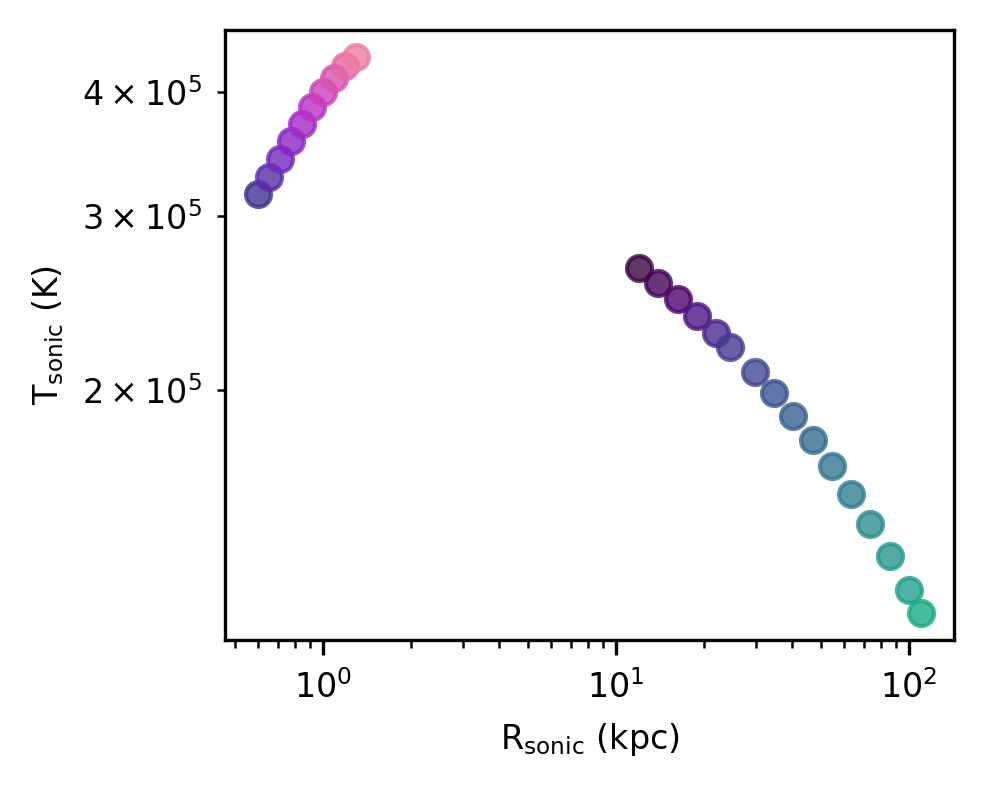

In [22]:
latexify(columns=1)
plt.figure()
ax = plt.gca()

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        T_sonic = res.Ts[mach_crossings[0]]
        plt.scatter(res.R_sonic, T_sonic, alpha=0.8, color=colors[i])

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        T_sonic = res.Ts[mach_crossings[0]]
        plt.scatter(res.R_sonic, T_sonic, alpha=0.8, color=colors2[i])

ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0.1, 2)
# ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'T$_{\rm sonic}$ (K)')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8)

plt.tight_layout()
# plt.savefig('./plots/cf_mdot.pdf',dpi=300)
plt.show()

/tmp/ipykernel_449089/4072894786.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, handlelength=1.8)


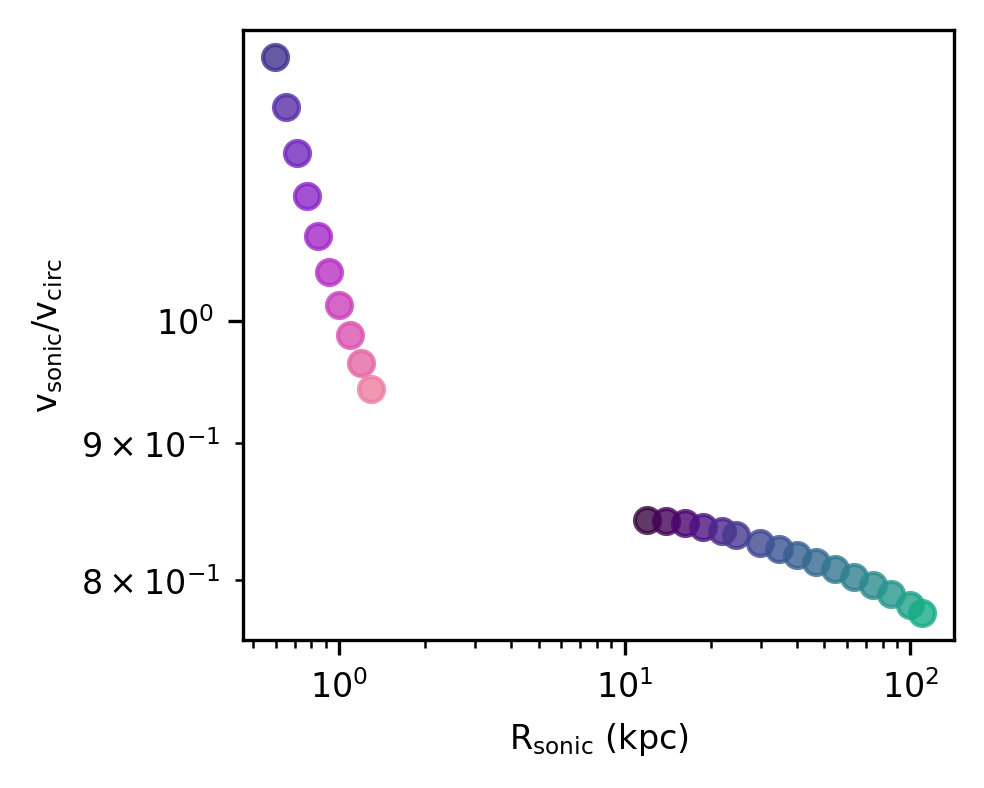

In [27]:
v_circ = combined.vc(r_ref).to('km/s')

latexify(columns=1)
plt.figure()
ax = plt.gca()

for i in range(len(loaded_solutions)):
    res = loaded_solutions[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        v_r = res.vs[mach_crossings[0]]
        cs = res.cs[mach_crossings[0]]
        v_circ = combined.vc(res.R_sonic).to('km/s')
        plt.scatter(res.R_sonic, v_r/v_circ, alpha=0.8, color=colors[i])

for i in range(len(loaded_solutions2)):
    res = loaded_solutions2[i]
    if res is not None:
        mach_crossings = np.where(np.diff(np.signbit(res.Ms - 1)))[0]
        v_r = res.vs[mach_crossings[0]]
        v_circ = combined.vc(res.R_sonic).to('km/s')
        plt.scatter(res.R_sonic, v_r/v_circ, alpha=0.8, color=colors2[i])

ax.set_xscale('log')
ax.set_yscale('log')
# ax.set_ylim(0.1, 2)
# ax.set_xlim(0.5,200)
ax.set_xlabel(r'R$_{\rm sonic}$ (kpc)')
ax.set_ylabel(r'v$_{\rm sonic}/$v$_{\rm circ}$')
# ax.tick_params(top=True, right=True, which="both", direction='in')
ax.legend(frameon=False, handlelength=1.8)

plt.tight_layout()
# plt.savefig('./plots/cf_mdot.pdf',dpi=300)
plt.show()

In [82]:
# latexify(columns=2)
# fig, axs = plt.subplots(2, 2)

# for ax in axs.flatten():
#     ax.set_xlabel(r'r (kpc)')
#     ax.set_xscale('log')
#     ax.set_yscale('log')
#     ax.tick_params(top=True, right=True, which="both", direction='in')
#     ax.set_xlim(1,200)

#     ax.axvline(r_gal,c='C9',ls='--',alpha=0.5)
#     ax.axvline(r_vir,c='C9',ls='--',alpha=0.5)

# colors = cmr.lavender(np.linspace(0.2,0.8,len(transsonic_solutions)))
# for i in range(len(transsonic_solutions)):
#     res = transsonic_solutions[i]
#     if res is not None:
#         axs[0, 0].plot(res.Rs, res.Ts, alpha=0.7, color=colors[i])
#         axs[0, 0].set_ylabel(r'T (K)')
#         axs[0, 0].set_ylim(1e4,1e6)
        
#         axs[0, 1].plot(res.Rs, res.nHs, alpha=0.7, color=colors[i], 
#                        label=f'{R_sonics[i].value:.0f} kpc')
#         axs[0, 1].set_ylabel(r'nH (cm$^{-3}$)')
#         axs[0, 1].set_ylim(1e-6,1e-1)
        
#         axs[1, 0].axhline(1.,c='C9',ls='--',alpha=0.5)
#         axs[1, 0].plot(res.Rs, res.Ms, alpha=0.7, color=colors[i], 
#                        label=f'{R_sonics[i].value:.0f} kpc')
#         axs[1, 0].set_ylabel(r'M')
#         axs[1, 0].set_ylim(0.02,20)
        
#         axs[1, 1].axhline(1.,c='C9',ls='--',alpha=0.5)
#         axs[1, 1].plot(res.Rs, res.t_cools / res.t_flows, alpha=0.7, color=colors[i])
#         axs[1, 1].set_ylabel(r't$_{\rm cool}/$t$_{\rm flow}$')
#         axs[1, 1].set_ylim(0.1,10)

#         # print(res.mass_flow_rate)

# axs[1, 0].legend(frameon=True, ncols=3, title=r'R$_{\rm sonic}$', handlelength=1.8)
# plt.tight_layout()
# # plt.savefig('./plots/cf_sols.pdf',dpi=300)
# plt.show()